In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import util
import importlib
importlib.reload(util)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
random_state = 42

# 1. Load, clean and merge the datasets

In [3]:
data_dir = Path('datasets')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

we_df_path = data_dir / 'WeatherEvents_Jan2016-Dec2022.csv'

target_df = util.load_datasets(files)

we_df = util.load_datasets(we_df_path)

In [4]:
# Drop useful columns
useful_column = [
    'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID',
    'EVENT_ID',
    'STATE_FIPS',
    'YEAR',
    'MONTH_NAME',
    'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
    'WFO',
    'CZ_TIMEZONE',
    'INJURIES_DIRECT', 'INJURIES_INDIRECT', 
    'DEATHS_DIRECT', 'DEATHS_INDIRECT',  
    'DAMAGE_PROPERTY', 'DAMAGE_CROPS',
    'SOURCE',
    'MAGNITUDE',
    'MAGNITUDE_TYPE',
    'FLOOD_CAUSE', 
    'CATEGORY', 
    'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 
    'BEGIN_RANGE', 'BEGIN_AZIMUTH',
    'END_RANGE', 'END_AZIMUTH',
    'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'
    

]

target_df1 = target_df.drop(columns=useful_column, axis=0).copy()

# Keep only flood events
target_df2 = target_df1[target_df1['EVENT_TYPE'] == 'Flood'].copy()
target_df2.shape

(20644, 10)

In [5]:
# Drop useful columns
useful_we_column = [
    'EventId',
    'Severity',
    'TimeZone',
    'AirportCode',
    'County',
    'ZipCode'
]

we_df1 = we_df.drop(columns=useful_we_column, axis=0).copy()
we_df1.columns

# Keep only rain events
we_df2 = we_df1[we_df1['Type']=='Rain'].copy()
we_df2.shape

(5000794, 8)

In [6]:
# parsing data flood
target_df2['date'] = pd.to_datetime(
    target_df2['BEGIN_DATE_TIME'], 
    format='%d-%b-%y %H:%M:%S',
    errors='coerce'
)

target_df2 = target_df2.dropna(subset=['date'])

target_df2[['BEGIN_DATE_TIME', 'date']].head()

,BEGIN_DATE_TIME,date
40,25-FEB-16 11:57:00,2016-02-25 11:57:00
41,24-FEB-16 20:16:00,2016-02-24 20:16:00
43,24-FEB-16 23:36:00,2016-02-24 23:36:00
44,24-FEB-16 21:37:00,2016-02-24 21:37:00
112,24-FEB-16 23:04:00,2016-02-24 23:04:00


In [7]:
# Group and sum all the rain (for every day and every state)
we_df2['date_day'] = pd.to_datetime(we_df2['StartTime(UTC)']).dt.date
rain_daily = we_df2.groupby(['State', 'date_day'])['Precipitation(in)'].sum().reset_index()
rain_daily.columns = ['state', 'date', 'precipitation']

In [8]:
# Create features flood_count and is_flood
target_df2['date_day'] = target_df2['date'].dt.date
flood_events = target_df2.groupby(['STATE', 'date_day']).size().reset_index(name='flood_count') # Number of floods in that day, in that state
flood_events['is_flood'] = 1 # At least one flood happens
flood_events.columns = ['state', 'date', 'flood_count', 'is_flood']
flood_events.head()

,state,date,flood_count,is_flood
0,ALABAMA,2016-02-02,1,1
1,ALABAMA,2016-02-23,1,1
2,ALABAMA,2016-02-24,3,1
3,ALABAMA,2016-03-24,3,1
4,ALABAMA,2016-04-01,1,1


In [9]:
# Map state names to their abbreviation to match the ones in the weather dataset
flood_events['state'] = flood_events['state'].map(util.map_state_abbrev)
flood_events = flood_events.dropna(subset=['state'])
flood_events.head()

,state,date,flood_count,is_flood
0,AL,2016-02-02,1,1
1,AL,2016-02-23,1,1
2,AL,2016-02-24,3,1
3,AL,2016-03-24,3,1
4,AL,2016-04-01,1,1


In [10]:
# Merge the two datasets
ts_df = pd.merge(rain_daily, flood_events, on=['state', 'date'], how='left')
ts_df['is_flood'] = ts_df['is_flood'].fillna(0) # 0 id there were no flood on that day
ts_df['date'] = pd.to_datetime(ts_df['date'])
ts_df.head()

,state,date,precipitation,flood_count,is_flood
0,AL,2016-01-01,1.13,NaN,0.0
1,AL,2016-01-02,0.00,NaN,0.0
2,AL,2016-01-03,0.00,NaN,0.0
3,AL,2016-01-04,0.00,NaN,0.0
4,AL,2016-01-05,0.00,NaN,0.0


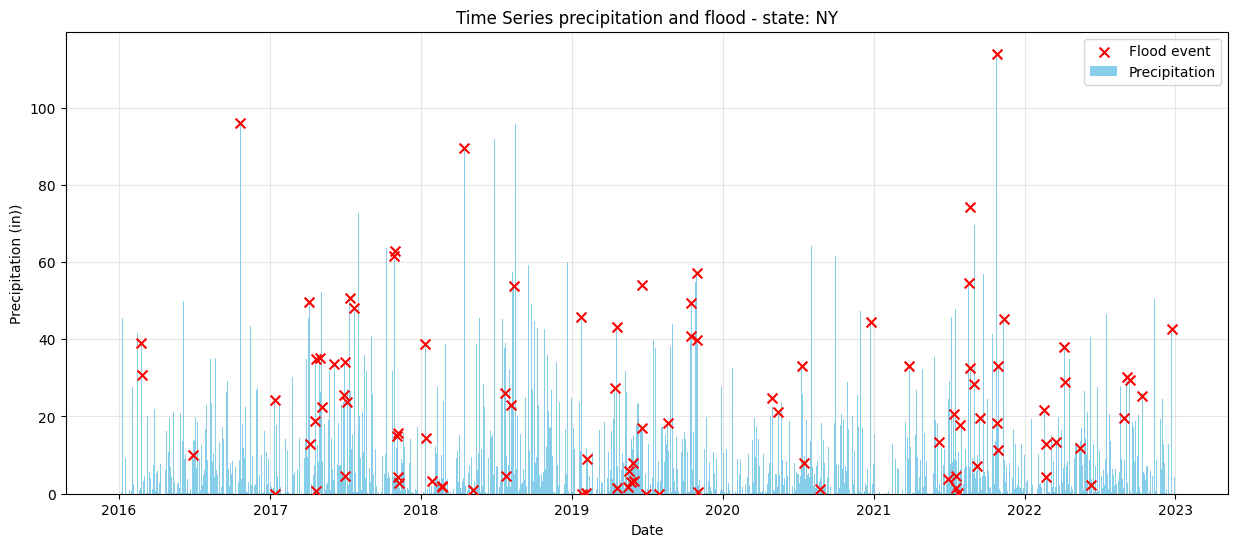

In [11]:
util.plot_state_series('NY', ts_df)

# 2. Implementation GMM

In [12]:
# Configuration
STATES_TO_ANALYZE = ['TX', 'AL', 'NY']
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
WINDOW_SIZE = 7
THRESHOLD_PERCENTILE = 4

# Define a cost function
C_ALARM = 1
C_MISSED = 8
TOLERANCE = 1

## 2a. GridSearch + Cross Validation

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


##############################
Analyzing state: TX
##############################
Split: Train=1507, Val=502, Test=503
Best parameters: {'n_components': 9}
Best score: -0.26
Optimizing threshold on Validation Set...
Best Threshold Found: 6.71 (Min Cost: 380)
Anomaly Threshold (Log-Likelihood): 6.71

Confusion Matrix (WITHOUT tolerance):
  TP=26, FP=477, FN=0, TN=0

Metrics WITH tolerance (±1 day):
  False Positives: 437
  False Negatives: 0
  Total Cost: 437


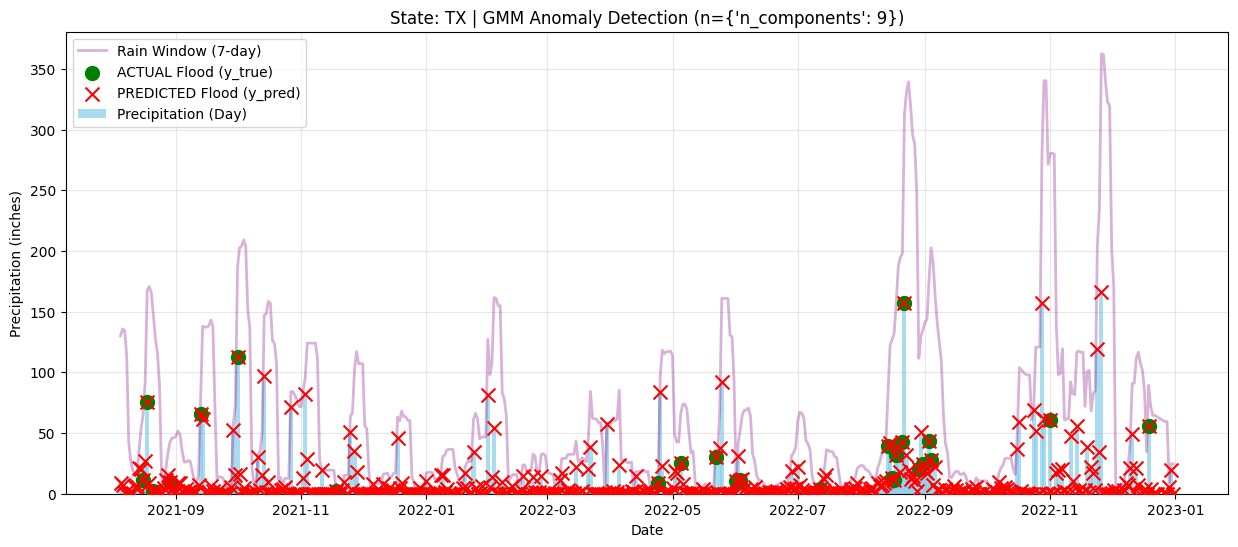


##############################
Analyzing state: AL
##############################
Split: Train=1306, Val=435, Test=436
Best parameters: {'n_components': 5}
Best score: -1.28
Optimizing threshold on Validation Set...
Best Threshold Found: -2.61 (Min Cost: 34)
Anomaly Threshold (Log-Likelihood): -2.61

Confusion Matrix (WITHOUT tolerance):
  TP=3, FP=96, FN=4, TN=333

Metrics WITH tolerance (±1 day):
  False Positives: 89
  False Negatives: 0
  Total Cost: 89


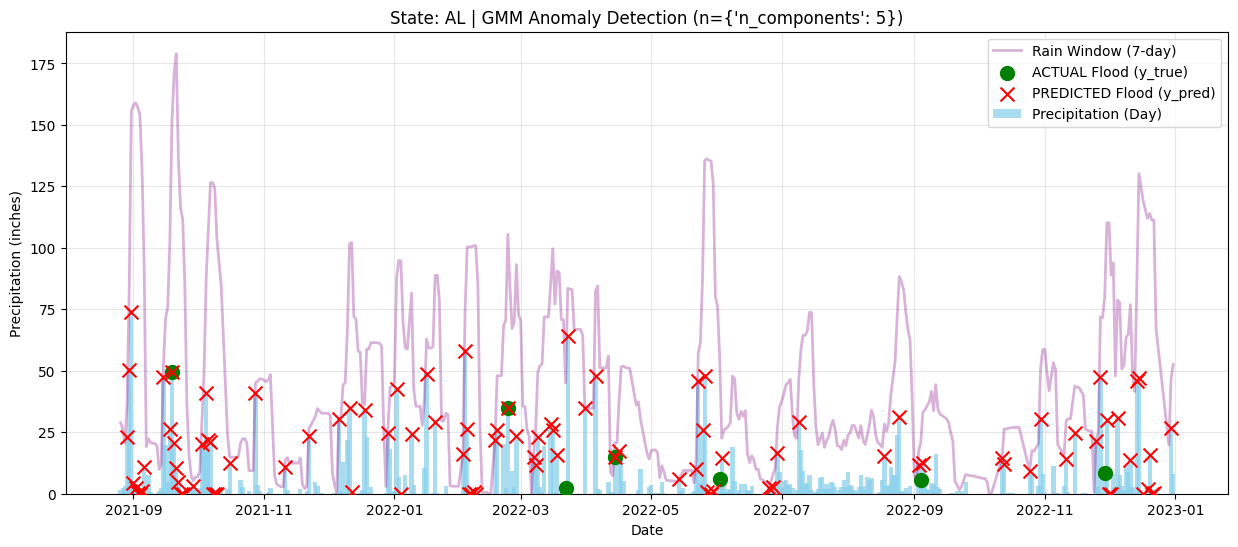


##############################
Analyzing state: NY
##############################
Split: Train=1311, Val=437, Test=438
Best parameters: {'n_components': 7}
Best score: -1.22
Optimizing threshold on Validation Set...
Best Threshold Found: -3.14 (Min Cost: 112)
Anomaly Threshold (Log-Likelihood): -3.14

Confusion Matrix (WITHOUT tolerance):
  TP=20, FP=88, FN=4, TN=326

Metrics WITH tolerance (±1 day):
  False Positives: 74
  False Negatives: 3
  Total Cost: 98


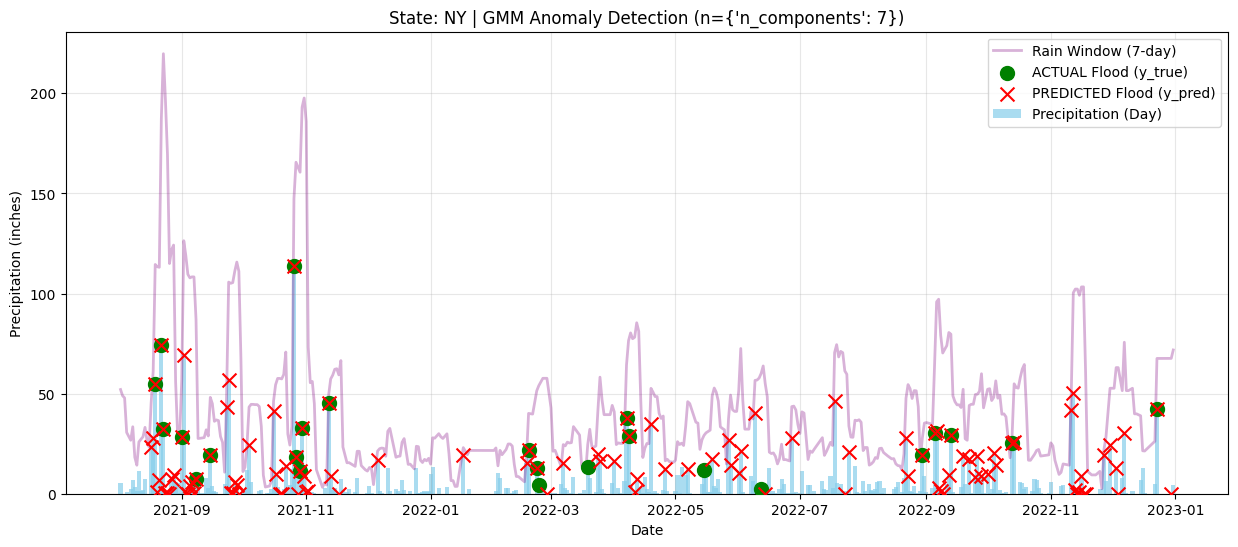

In [16]:
for state in STATES_TO_ANALYZE:
    print(f"\n{'#'*30}\nAnalyzing state: {state}\n{'#'*30}")
    
    data = util.state_df_rolling_ws(ts_df, state, WINDOW_SIZE)
    
    # 1. Temporal Split
    n = len(data)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * (TRAIN_RATIO + VAL_RATIO))
    
    train_data = data.iloc[:n_train]
    val_data = data.iloc[n_train:n_val]
    test_data = data.iloc[n_val:]
    
    print(f"Split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    ## Plot of the split
    #plt.figure(figsize=(10, 3))
    #plt.plot(train_data['date'], train_data['precipitation'], label='Train (Rain)', color='blue', alpha=0.5)
    #plt.plot(test_data['date'], test_data['precipitation'], label='Test (Rain)', color='orange', alpha=0.5)
    #plt.title(f"{state}: Train/Test Split")
    #plt.legend()
    #plt.show()

    # 2. Data standardization
    X_train = train_data[['precipitation', 'rain_window']].values
    X_val = val_data[['precipitation', 'rain_window']].values
    y_val = val_data[['is_flood']].values
    X_test = test_data[['precipitation', 'rain_window']].values
    y_test = test_data['is_flood'].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.fit_transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # 3. Train GMM with GridSearch + cross validation (train set)
    cv_split = TimeSeriesSplit(n_splits=5)
    param_grid = {'n_components' : list(range(1,10))}
    gmm = GaussianMixture(
        max_iter=200,
        n_init=10,
        tol=1e-3,
        random_state=random_state
        )

    opt = GridSearchCV(estimator=gmm,
                       param_grid=param_grid,
                       cv=cv_split)
    
    opt.fit(X_train_scaled)

    best_model = opt.best_estimator_
    print(f"Best parameters: {opt.best_params_}")
    print(f"Best score: {opt.best_score_:.2f}")

    # 4. Threshold optimization (val set)
    print("Optimizing threshold on Validation Set...")
    val_scores = -opt.score_samples(X_val_scaled)
    possible_thresholds = np.linspace(val_scores.min(), val_scores.max(), 100)

    cost_model = util.FloodCostModel(C_ALARM, C_MISSED, TOLERANCE)
    
    best_thr, best_cost = util.opt_threshold(val_scores, y_val.flatten(), possible_thresholds, cost_model)
    print(f"Best Threshold Found: {best_thr:.2f} (Min Cost: {best_cost})")

    # 5. Prediction (test set)
    test_log_likelihood = best_model.score_samples(X_test_scaled)

    # 6. Metrics
    # With temporal tolerance
    test_cost = cost_model.cost(test_log_likelihood, y_test, best_thr)
    test_fp, test_fn = util.get_errors(test_log_likelihood, y_test, best_thr, tolerance=1)

    # Without temporal tolerance (standard cm)
    y_pred = (test_log_likelihood < best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    print(f"Anomaly Threshold (Log-Likelihood): {best_thr:.2f}")
    print(f"\nConfusion Matrix (WITHOUT tolerance):")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"\nMetrics WITH tolerance (±{TOLERANCE} day):")
    print(f"  False Positives: {len(test_fp)}")
    print(f"  False Negatives: {len(test_fn)}")
    print(f"  Total Cost: {test_cost}")
        
    # 7. --- FINAL PLOT ---
    plt.figure(figsize=(15, 6))
    
    # A1) Barplot of Precipitation
    plt.bar(test_data['date'], test_data['precipitation'], color='skyblue', label='Precipitation (Day)', width=2, alpha=0.7)
    
    # A2) Line plot of Rain Window
    plt.plot(test_data['date'], test_data['rain_window'], color='purple', label='Rain Window (7-day)', alpha=0.3, linewidth=2)
    
    # B) True Floods (y_true)
    true_floods = test_data[test_data['is_flood'] == 1]
    plt.scatter(true_floods['date'], true_floods['precipitation'], 
                color='green', s=100, marker='o', label='ACTUAL Flood (y_true)', zorder=5)
    
    # C) Predicted Floods (y_pred)
    pred_indices = np.where(y_pred == 1)[0]
    pred_dates = test_data.iloc[pred_indices]['date']
    pred_vals = test_data.iloc[pred_indices]['precipitation']
    
    plt.scatter(pred_dates, pred_vals, 
                color='red', s=100, marker='x', label='PREDICTED Flood (y_pred)', zorder=6)
    
    plt.title(f"State: {state} | GMM Anomaly Detection (n={opt.best_params_})")
    plt.xlabel("Date")
    plt.ylabel("Precipitation (inches)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()